In [1]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import rasterio

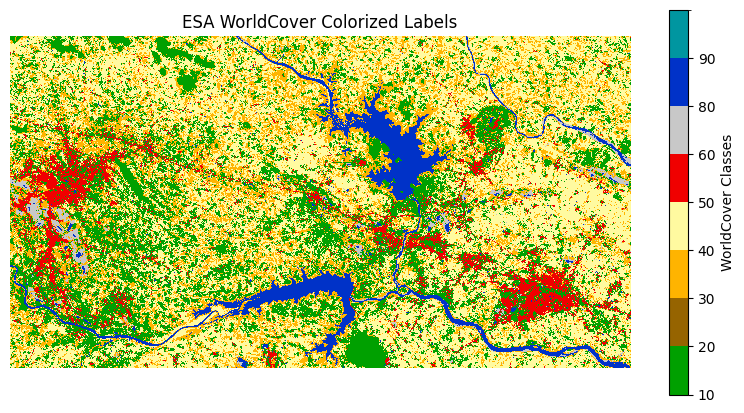

In [ ]:

worldcover_palette = {
    10: [0, 160, 0],    
    20: [150, 100, 0],    
    30: [255, 180, 0],   
    40: [255, 250, 160], 
    50: [240, 0, 0],      
    60: [200, 200, 200],
    80: [0, 50, 200],  
    90: [0, 150, 160]
}

with rasterio.open(r"D:\Resume Projs\EcoRouteAI\Dataset\Processed Data\Labels.tif") as src:
    grayscale_array = src.read(1)

colors_normalized = [np.array(worldcover_palette[k]) / 255.0 for k in sorted(worldcover_palette.keys())]
cmap = mcolors.ListedColormap(colors_normalized)

bounds = sorted(list(worldcover_palette.keys())) + [105] 
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(grayscale_array, cmap=cmap, norm=norm, interpolation='nearest')
ax.axis('off')
ax.set_title("ESA WorldCover Colorized Labels")
plt.colorbar(im, ticks=sorted(worldcover_palette.keys()), label="WorldCover Classes", shrink= 0.5)
plt.show()

In [ ]:
#Cost Surface

with rasterio.open(r"Dataset\Processed Data\CostSurface.tif") as src:
    cost_surface = src.read(1)

masked_cost = np.ma.masked_equal(cost_surface, 9999)

cmap = cm.get_cmap("RdYlGn_r").copy()

cmap.set_bad(color="#222222", alpha=1.0)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(masked_cost, cmap=cmap, vmin=1, vmax=10)

cbar = fig.colorbar(im, ax=ax, orientation="vertical", shrink=0.5)
cbar.set_label("Travel Cost Scale", fontsize=12, labelpad=10)
cbar.ax.set_title("Impassable\n(9999)", fontsize=10, pad=10, color="red")

ax.set_title("Weighted Cost Surface Base Map", fontsize=14, pad=15)
ax.axis('off')

ax.grid(False) 
plt.tight_layout()
plt.savefig("cost_surface_gradient.png", dpi=300)
plt.close()